In [17]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

#Import the Dataset
df= pd.read_csv("../dataset/english_osint_dataset.csv")
df= df.drop(columns=['latency','scan_duration'])
display(df.head(20))


,email_text,hostname,scan_duration,host_up,alternate_ip_count,ip_address,common_web_ports_open,open_ports_count,latency,filtered_ports_count,open_ports,rdns_record,https_supported,services,host_found,interesting_url,asn_found,ip_found,email_type
0,Hello I am your hot lil horny toy.\n I am t...,www.mail.com,43.17,1,0,82.165.229.59,1,3,0.0031,996,"443, 8008, 80",NaN,1,"http, https",0,0,0,0,Phishing Email
1,"On Sun, Aug 11, 2002 at 11:17:47AM +0100, wint...",NaN,0.12,0,0,NaN,0,0,NaN,0,NaN,NaN,0,NaN,0,0,0,0,Safe Email
2,"URL: http://www.newsisfree.com/click/-5,830431...",www.newsisfree.com,43.78,1,1,104.21.22.148,1,5,0.0096,994,"80, 8008, 8080, 8443, 443",NaN,1,"http-proxy, http, https-alt, https",0,0,0,0,Safe Email
3,"begin forwarded text Date: Wed, 25 Sep 2002 13...","www.siliconvalley.com, www.ceert.org","42.37, 87.48",1,0,"72.167.68.110, 192.0.66.2",1,"11, 3","0.0028, 0.16","996, 982","110, 21, 22, 993, 80, 995, 8008, 443, 8008, 80...",", 110.68.167.72.host.secureserver.net",1,"mysql, ssh, pop3, imaps, ftp, imap, http, http...",0,0,0,0,Safe Email
4,The academic discipline of Software Engineerin...,www.cs.ncl.ac.uk,52.58,1,0,128.240.208.85,1,3,0.077,996,"443, 8008, 80",apps-extweb-l.ncl.ac.uk,1,"http, https",0,0,0,0,Safe Email
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1479,"Two issues:----\nSorry, but the following pack...",NaN,0.13,0,0,NaN,0,0,NaN,0,NaN,NaN,0,NaN,0,0,0,0,Safe Email
1480,"howdy all,I have in my possession the followin...",", www.physics.dcu.ie","0.08, 50.28","0, 1",0,", 136.206.33.196","0, 1","4, 0",", 0.072","0, 995",", 22, 80, 8008, 443",", frank.physics.dcu.ie","0, 1",", ssh, http, https","0, 6","0, 1","0, 1","0, 4",Safe Email
1481,Sorry i know this is off topic:Ive recently go...,NaN,0.04,0,0,NaN,0,0,NaN,0,NaN,NaN,0,NaN,0,0,0,0,Safe Email
1482,"At 3:39 PM -0500 8/21/02, Rice, MA Mark (6750 ...","lists.sourceforge.net, www.inphonic.com","116.94, 44.03",1,0,"216.105.38.7, 204.235.124.180","0, 1","1, 3","0.003, 0.21","996, 998","443, 8008, 80, 8008",", inphonic.com","0, 1","http, https, http",0,"0, 2",0,"1, 2",Safe Email


In [18]:
int_keys = ["ip_found","host_found","interesting_url","asn_found","ip_found",
            "host_up","alternate_ip_count","common_web_ports_open","filtered_ports_count",
            "https_supported","open_ports_count"]
for itm in int_keys:
    df[itm].fillna(0,inplace = True) 

string_keys=["hostname","ip_address","services","open_ports","rdns_record"]
for itm in string_keys:
    df[itm].fillna('',inplace = True)

C:\Users\Rana Shafi\AppData\Local\Temp\ipykernel_14364\2475762194.py:6: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[itm].fillna(0,inplace = True)
C:\Users\Rana Shafi\AppData\Local\Temp\ipykernel_14364\2475762194.py:10: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example,

In [ ]:
#Check for missing values¶
df.isnull().sum()


email_text               0
hostname                 0
scan_duration            0
host_up                  0
alternate_ip_count       0
ip_address               0
common_web_ports_open    0
open_ports_count         0
latency                  0
filtered_ports_count     0
open_ports               0
rdns_record              0
https_supported          0
services                 0
host_found               0
interesting_url          0
asn_found                0
ip_found                 0
email_type               0
dtype: int64

In [20]:
# Handle integer columns
int_keys = [
    "ip_found", "host_found", "interesting_url", "asn_found", "host_up",
    "alternate_ip_count", "common_web_ports_open", "filtered_ports_count",
    "https_supported", "open_ports_count"
]
for itm in int_keys:
    # Convert to numeric, coerce errors, and fill NaN with 0 before converting to int
    df[itm] = pd.to_numeric(df[itm], errors="coerce").fillna(0).astype("int")


In [21]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1484 entries, 0 to 1483
Data columns (total 19 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   email_text             1484 non-null   object 
 1   hostname               1484 non-null   object 
 2   scan_duration          1484 non-null   float64
 3   host_up                1484 non-null   int64  
 4   alternate_ip_count     1484 non-null   int64  
 5   ip_address             1484 non-null   object 
 6   common_web_ports_open  1484 non-null   int64  
 7   open_ports_count       1484 non-null   int64  
 8   latency                1484 non-null   float64
 9   filtered_ports_count   1484 non-null   int64  
 10  open_ports             1484 non-null   object 
 11  rdns_record            1484 non-null   object 
 12  https_supported        1484 non-null   int64  
 13  services               1484 non-null   object 
 14  host_found             1484 non-null   int64  
 15  inte

In [22]:
# Check for duplicate values¶
display(df)

,email_text,hostname,scan_duration,host_up,alternate_ip_count,ip_address,common_web_ports_open,open_ports_count,latency,filtered_ports_count,open_ports,rdns_record,https_supported,services,host_found,interesting_url,asn_found,ip_found,email_type
0,Hello I am your hot lil horny toy.\n I am t...,www.mail.com,43.17,1,0,82.165.229.59,1,3,0.0031,996,"443, 8008, 80",,1,"http, https",0,0,0,0,Phishing Email
1,"On Sun, Aug 11, 2002 at 11:17:47AM +0100, wint...",,0.12,0,0,,0,0,0.0000,0,,,0,,0,0,0,0,Safe Email
2,"URL: http://www.newsisfree.com/click/-5,830431...",www.newsisfree.com,43.78,1,1,104.21.22.148,1,5,0.0096,994,"80, 8008, 8080, 8443, 443",,1,"http-proxy, http, https-alt, https",0,0,0,0,Safe Email
3,"begin forwarded text Date: Wed, 25 Sep 2002 13...","www.siliconvalley.com, www.ceert.org",0.00,1,0,"72.167.68.110, 192.0.66.2",1,0,0.0000,0,"110, 21, 22, 993, 80, 995, 8008, 443, 8008, 80...",", 110.68.167.72.host.secureserver.net",1,"mysql, ssh, pop3, imaps, ftp, imap, http, http...",0,0,0,0,Safe Email
4,The academic discipline of Software Engineerin...,www.cs.ncl.ac.uk,52.58,1,0,128.240.208.85,1,3,0.0770,996,"443, 8008, 80",apps-extweb-l.ncl.ac.uk,1,"http, https",0,0,0,0,Safe Email
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1479,"Two issues:----\nSorry, but the following pack...",,0.13,0,0,,0,0,0.0000,0,,,0,,0,0,0,0,Safe Email
1480,"howdy all,I have in my possession the followin...",", www.physics.dcu.ie",0.00,0,0,", 136.206.33.196",0,0,0.0000,0,", 22, 80, 8008, 443",", frank.physics.dcu.ie",0,", ssh, http, https",0,0,0,0,Safe Email
1481,Sorry i know this is off topic:Ive recently go...,,0.04,0,0,,0,0,0.0000,0,,,0,,0,0,0,0,Safe Email
1482,"At 3:39 PM -0500 8/21/02, Rice, MA Mark (6750 ...","lists.sourceforge.net, www.inphonic.com",0.00,1,0,"216.105.38.7, 204.235.124.180",0,0,0.0000,0,"443, 8008, 80, 8008",", inphonic.com",0,"http, https, http",0,0,0,0,Safe Email


In [23]:
# # Count the occurrences of each E-mail type. 
email_type_counts = df['email_type'].value_counts()
print(email_type_counts)

email_type
Safe Email        1232
Phishing Email     252
Name: count, dtype: int64


In [ ]:
# # We will use undersapling technique 
Safe_Email = df[df["email_type"]== "Safe Email"]
Phishing_Email = df[df["email_type"]== "Phishing Email"]
Safe_Email = Safe_Email.sample(Phishing_Email.shape[0])

In [ ]:
# lets check the sahpe again 
Safe_Email.shape,Phishing_Email.shape

In [ ]:
# lest create a new Data with the balanced E-mail types
Data= pd.concat([Safe_Email, Phishing_Email], ignore_index = True)
Data.head()
display(Data)

In [25]:

# import numpy as np
# import pandas as pd
# import seaborn as sns
# import matplotlib.pyplot as plt
# from wordcloud import WordCloud
# # Pie chart visualization¶
# #We will use the pie chart to compare the data of Safe Type and Phishing Type.

# email_type = df['email_type'].value_counts()

# # Pie chart
# plt.pie(email_type, colors=['darkorange', 'darkred'], autopct='%1.1f%%')
# plt.title('Total of email texts')
# plt.legend(['Safe', 'Phishing'], title='Email Type')
# plt.show()

C:\Users\Rana Shafi\AppData\Local\Temp\ipykernel_14364\448206467.py:15: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['email_type'] = df['email_type'].replace({'Safe Email': 0, 'Phishing Email': 1}).astype(int)


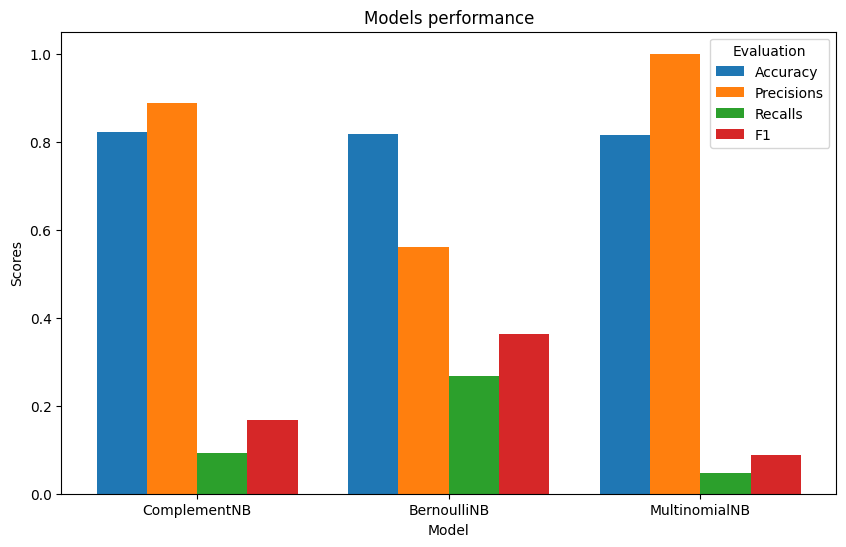

In [26]:
# import numpy as np
# import pandas as pd
# from sklearn.naive_bayes import ComplementNB, BernoulliNB, MultinomialNB
# from sklearn.model_selection import train_test_split
# from sklearn.feature_extraction.text import TfidfVectorizer
# from sklearn.preprocessing import StandardScaler, OneHotEncoder, LabelEncoder
# from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
# import matplotlib.pyplot as plt
# from sklearn.compose import ColumnTransformer
# from sklearn.pipeline import Pipeline
# from scipy.sparse import hstack


# # Replace labels and convert to integer
# df['email_type'] = df['email_type'].replace({'Safe Email': 0, 'Phishing Email': 1}).astype(int)

# # Define models and names
# models = [ComplementNB(), BernoulliNB(), MultinomialNB()]
# model_names = ['ComplementNB', 'BernoulliNB', 'MultinomialNB']

# accuracies = []
# precisions = []
# recalls = []
# f1 = []

# # Convert email text feature using TF-IDF
# tfidf = TfidfVectorizer()
# X_text = tfidf.fit_transform(df['email_text'])

# categorical_features = ['hostname', 'rdns_record', 'services', 'ip_address', 'open_ports']
# numerical_features = [
#     'host_up', 'alternate_ip_count', 'common_web_ports_open',
#     'open_ports_count', 'filtered_ports_count', 'https_supported',
#     'host_found', 'interesting_url', 'asn_found', 'ip_found'
# ]

# # Handle missing values (fill numeric with 0, categorical with "unknown")
# df[numerical_features] = df[numerical_features].fillna(0)
# df[categorical_features] = df[categorical_features].fillna('unknown')

# # Encode categorical features using OneHotEncoder
# onehot = OneHotEncoder(handle_unknown='ignore')
# encoded_categorical = onehot.fit_transform(df[categorical_features])

# from sklearn.preprocessing import MinMaxScaler

# # Replace StandardScaler with MinMaxScaler
# scaler = MinMaxScaler()
# scaled_numerical = scaler.fit_transform(df[numerical_features])

# # Combine categorical and numerical features
# X_additional = hstack([encoded_categorical, scaled_numerical])

# tfidf = TfidfVectorizer()
# X_text = tfidf.fit_transform(df['email_text'])

# # Combine TF-IDF-transformed text and additional features
# X_combined = hstack([X_text, X_additional])

# # Standardize numerical features
# # scaler = StandardScaler()
# # scaled_numerical = scaler.fit_transform(df[numerical_features])

# # Combine categorical and numerical features
# # X_additional = hstack([encoded_categorical, scaled_numerical])

# # Convert email text using TF-IDF


# # X_combined = hstack([X_text, X_additional])  # Combine sparse matrix and dense array

# # Define the target variable
# Y = df['email_type']

# # Split into training and testing sets
# X_train, X_test, y_train, y_test = train_test_split(X_combined, Y, test_size=0.3, random_state=42)

# # Calculate the performance
# for model in models:
#     model.fit(X_train, y_train)
#     pred = model.predict(X_test)

#     accuracies.append(accuracy_score(y_test, pred))
#     precisions.append(precision_score(y_test, pred))
#     recalls.append(recall_score(y_test, pred))
#     f1.append(f1_score(y_test, pred))

# # Plot results
# axis = np.arange(len(model_names))

# plt.figure(figsize=(10, 6))
# plt.bar(axis - 0.3, accuracies, 0.2, label='Accuracy') 
# plt.bar(axis - 0.1, precisions, 0.2, label='Precisions')
# plt.bar(axis + 0.1, recalls, 0.2, label='Recalls')
# plt.bar(axis + 0.3, f1, 0.2, label='F1')

# plt.xticks(axis, model_names) 
# plt.xlabel("Model") 
# plt.ylabel("Scores") 
# plt.title("Models performance") 
# plt.legend(title="Evaluation") 
# plt.show()

Accuracy: 0.8161434977578476
Precision: 1.0
Recall: 0.046511627906976744
F1 Score: 0.08888888888888889
Confusion Matrix:
[[360   0]
 [ 82   4]]


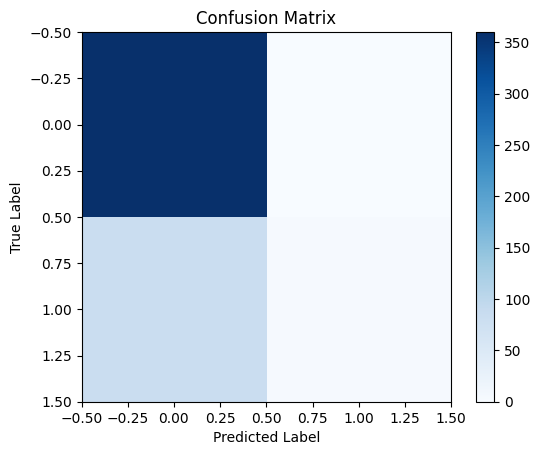

In [30]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import OneHotEncoder, MinMaxScaler
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
from scipy.sparse import hstack
import matplotlib.pyplot as plt

# Replace labels and convert to integer
df['email_type'] = df['email_type'].replace({'Safe Email': 0, 'Phishing Email': 1}).astype(int)

# Define categorical and numerical features
categorical_features = ['hostname', 'rdns_record', 'services', 'ip_address', 'open_ports']
numerical_features = [
    'host_up', 'alternate_ip_count', 'common_web_ports_open',
    'open_ports_count', 'filtered_ports_count', 'https_supported',
    'host_found', 'interesting_url', 'asn_found', 'ip_found'
]

# Handle missing values
df[numerical_features] = df[numerical_features].fillna(0)
df[categorical_features] = df[categorical_features].fillna('unknown')

# Encode categorical features
onehot = OneHotEncoder(handle_unknown='ignore')
encoded_categorical = onehot.fit_transform(df[categorical_features])

# Scale numerical features
scaler = MinMaxScaler()
scaled_numerical = scaler.fit_transform(df[numerical_features])

# Convert email text feature using TF-IDF
tfidf = TfidfVectorizer()
X_text = tfidf.fit_transform(df['email_text'])

# Combine TF-IDF-transformed text and additional features
X_combined = hstack([X_text, encoded_categorical, scaled_numerical])

# Define the target variable
Y = df['email_type']

# Split into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X_combined, Y, test_size=0.3, random_state=42)

# Instantiate the Naive Bayes model (MultinomialNB)
model = MultinomialNB()

# Fit the model
model.fit(X_train, y_train)

# Predict with the model
y_pred = model.predict(X_test)

# Evaluate the model
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

# Print evaluation metrics
print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)
print("F1 Score:", f1)

# Confusion Matrix
conf_matrix = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:")
print(conf_matrix)

# Plot Confusion Matrix (Optional)
plt.imshow(conf_matrix, cmap='Blues', interpolation='nearest')
plt.colorbar()
plt.title("Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()

In [31]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
output_file = "english_osint_nb_result.txt"

# Loop over each model to evaluate
for model in models:
    model_name = type(model).__name__
    print(f"Evaluating model: {model_name}")

    # Convert email text to TF-IDF features
    convert_feature = TfidfVectorizer()
    X = convert_feature.fit_transform(df['email_text'])
    Y = df['email_type']

    # Split data into train and test sets
    X_train, X_test, y_train, y_test = train_test_split(X, Y, test_size=0.3, random_state=42)

    # Train the model
    model.fit(X_train, y_train)

    # Predict on test set
    y_pred = model.predict(X_test)

    # Calculate accuracy
    accuracy = accuracy_score(y_test, y_pred)
    conf_matrix = confusion_matrix(y_test, y_pred)

    # Save results to the file
    with open(output_file, "a") as f:
        f.write(f"Model: {model_name}\n")
        f.write(f"Accuracy: {accuracy:.2f}\n")
        f.write("Confusion Matrix:\n")
        f.write("\n".join(" ".join(str(cell) for cell in row) for row in conf_matrix) + "\n")
        f.write("Classification Report:\n")
        f.write(classification_report(y_test, y_pred))
        f.write("-" * 50 + "\n")

    print(f"Results for {model_name} saved to {output_file}")


Evaluating model: ComplementNB
Results for ComplementNB saved to english_osint_nb_result.txt
Evaluating model: BernoulliNB
Results for BernoulliNB saved to english_osint_nb_result.txt
Evaluating model: MultinomialNB
Results for MultinomialNB saved to english_osint_nb_result.txt
